## Imports

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from collections import OrderedDict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision.models import resnet50, ResNet50_Weights, vit_b_32, ViT_B_32_Weights, convnext_base, ConvNeXt_Base_Weights
import matplotlib.pyplot as plt

from deepfake_utils.datasets import DeepFakeDataset
from deepfake_utils.models import MyModel
from deepfake_utils.train import validate_epoch

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [3]:
experiment_results = pd.read_csv("experiment_results.csv")

In [4]:
# focus on evaluating the best model settings for each family (i.e. 1 for ResNet, 1 for ViT, 1 for ConvNeXt)
# "best" is open to redefining a bit later depending on model complexity etc. but maybe just go with highest ROC AUC on validation data for now
experiment_results.sort_values(by='val_roc_auc', ascending = False).groupby("model").first()[['experiment_id', 'val_roc_auc', 'val_pr_auc', 'val_acc', 'val_loss', 'train_roc_auc', 'train_pr_auc', 'train_acc', 'train_loss']]
# experiment_results.sort_values(by='val_roc_auc', ascending = False).groupby("model").head(3)

,experiment_id,val_roc_auc,val_pr_auc,val_acc,val_loss,train_roc_auc,train_pr_auc,train_acc,train_loss
model,,,,,,,,,
ConvNeXt-base-pretrained,1,0.821407,0.875405,0.753425,0.904670,0.995513,0.997641,0.979487,0.066293
ResNet-50-pretrained,33,0.872955,0.921372,0.770548,0.842997,0.999989,0.999993,0.998535,0.010255
ViT-b32-pretrained,26,0.785433,0.847986,0.719178,0.540543,0.865407,0.907342,0.793407,0.453412


In [5]:
# load models with weights from training
# (most parameters if not all don't matter for inference)

# (I have no idea why the weight dictionary has "_orig_mod")
resnet_model_weights = OrderedDict([(k.replace("_orig_mod.", ""), v) for k, v in torch.load('experiment_33.pth', weights_only=True, map_location = device).items()])
resnet_model = MyModel("ResNet-50-pretrained", device, num_classes=2, freeze_layers=True)
resnet_model.load_state_dict(resnet_model_weights)

vit_model_weights = OrderedDict([(k.replace("_orig_mod.", ""), v) for k, v in torch.load('experiment_26.pth', weights_only=True, map_location = device).items()])
vit_model = MyModel("ViT-b32-pretrained", device, num_classes=2)
vit_model.load_state_dict(vit_model_weights)

convnext_model_weights = OrderedDict([(k.replace("_orig_mod.", ""), v) for k, v in torch.load('experiment_1.pth', weights_only=True, map_location = device).items()])
convnext_model = MyModel("ConvNeXt-base-pretrained", device, num_classes=2)
convnext_model.load_state_dict(convnext_model_weights)

<All keys matched successfully>

# Bias vs. Variance (Overfitting etc.)

In [6]:
train_loss_history = eval(experiment_results.sort_values(by='val_roc_auc', ascending=False).iloc[0]['train_loss_history'])
val_loss_history = eval(experiment_results.sort_values(by='val_roc_auc', ascending=False).iloc[0]['val_loss_history'])

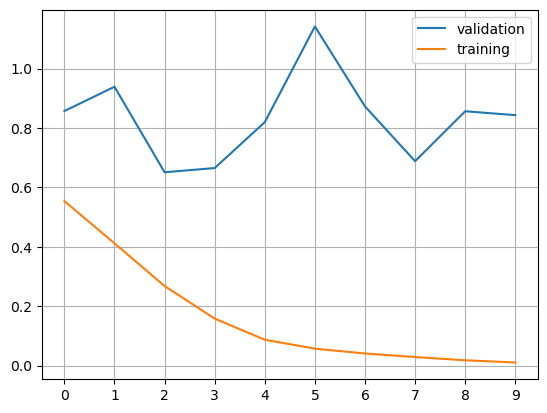

In [7]:
# if we end up showing learning curves in final report, maybe show 3 sets of train vs. val learning curves, 1 for each of the best 3 models
# see if it looks too crowded in 1 plot, or need to separate into 3 subplots side-by-side
 
plt.plot(val_loss_history, label = 'validation')
plt.plot(train_loss_history, label = 'training')
plt.xticks(np.arange(0,10,1))
plt.grid(axis = 'both')
plt.legend()
plt.show()

In [8]:
train_loss_history = eval(experiment_results.sort_values(by='val_roc_auc', ascending=False).iloc[0]['train_roc_auc_history'])
val_loss_history = eval(experiment_results.sort_values(by='val_roc_auc', ascending=False).iloc[0]['val_roc_auc_history'])

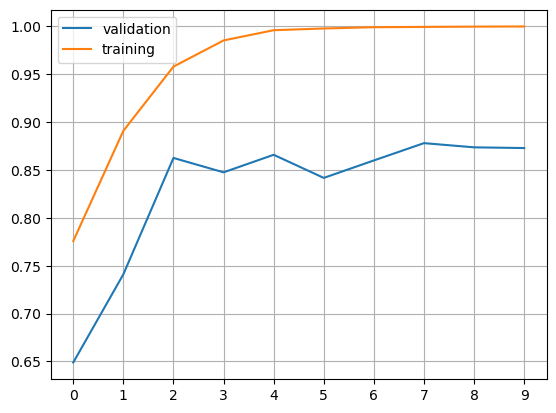

In [9]:
plt.plot(val_loss_history, label = 'validation')
plt.plot(train_loss_history, label = 'training')
plt.xticks(np.arange(0,10,1))
plt.grid(axis = 'both')
plt.legend()
plt.show()

## Evaluate Test Performance (ROC curves, precision-recall curves, tables etc.)

In [10]:
image_dir_path = 'Deepfake-Eval-2024/image-data'

In [18]:
debug_data = DeepFakeDataset("image-metadata-debug.csv", image_dir_path, model_type = 'ResNet', is_train = False)
debug_data_loader = DataLoader(debug_data, batch_size = 32, shuffle = False)

test_data = DeepFakeDataset("image-metadata-test.csv", image_dir_path, model_type = 'ResNet',  is_train = False)
test_data_loader = DataLoader(test_data, batch_size = 32, shuffle = False)

In [19]:
test_loss, test_roc_auc, test_pr_auc, test_accuracy = validate_epoch(test_data_loader, resnet_model, nn.CrossEntropyLoss(), device)

	Evaluation Progress: 	[  160/  293]
	Evaluation Progress: 	[  320/  293]


In [20]:
test_roc_auc, test_pr_auc, test_pr_auc, test_accuracy

(0.8486719592276781,
 0.9048176407814026,
 0.9048176407814026,
 0.7610921263694763)

In [ ]:
# maybe copy code from validate_epoch or create new utility function that returns the actual per-sample predictions so that we can plot ROC curves etc.
# this particular commit probably has tensors needed to do that
# https://github.com/Deepfake-Detection-KKO/deepfake-detection/blob/59df359e6d76043bd40df4a3fa0571ce67f79861/deepfake_utils/train.py

In [21]:
# Inference speed tests